In [1]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from astropy.io import fits
from astropy.io import fits
from astropy.table import Table
import json
import sys

In [2]:
sys.path.append(str(Path().resolve() / 'py_modules')) 

import list_maps_plots

Original Dr. Will Jupyter notebook
https://github.com/will-henney/lvm-turbulence/blob/main/lvm-tarantula-explore-122.ipynb

#  Data

In [3]:
line        = r'H$\alpha$'
lambda_rest = 6562.8
line_id     = 'H'
line_id2   = "6563"

In [4]:
#line        = r'[O II] $\lambda$3726'
#lambda_rest = 3726.03 
#line_id     = 'OIIb'
#line_id2   = "3726"

In [5]:
#line        = r'[O II] $\lambda$3729'
#lambda_rest = 3728.80 
#line_id     = 'OIIa'
#line_id2   = "3729"

In [6]:
#line        = r'[O III]$\lambda$ 5007'
#lambda_rest = 5006.9
#line_id     = 'OIIIa'
#line_id2   = "5007"

In [7]:
# Data from observations
bins        = 0

region     = 'NGC 2070'
name_reg   = '30 Doradus'
reg_id     = '30Dor'
inst       = 'LVM'
inst_id    = 'LVM'
type_obj   = 'H II region'

pix        = 0   # Instrument resolution [arcsec/pix]
dist       = 50000 # Distance [parsecs]
s0_        = 0.9    # proposed seeing

pc         = dist*(2*np.pi) / (360 * 60 * 60)
s0         = (s0_*pc)

#Since we are working with scatter adata there is no binning that can be applied
name_file    =  inst_id + '-' + reg_id + '-' + line_id2 
name_id      =  inst_id + '-' + reg_id + '-' + line_id2 + '_subrot'
print(name_file)
print(name_id)


LVM-30Dor-6563
LVM-30Dor-6563_subrot


In [8]:
_data = json.load(open('observations/'+ name_file + '-l.json'))
_line = pd.DataFrame(_data['data'])
_line.columns = ['RAdeg', 'DEdeg', 'V_mean','log_F','sigma']
#_line = _line[0:3500]

In [9]:
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.wcs import WCS

c0 = SkyCoord.from_name("Tarantula")
c0

<SkyCoord (ICRS): (ra, dec) in deg
    (84.675, -69.1)>

In [10]:
fov_deg = 1.0  # Total field of view in degrees (width and height)
pix_scale = 1 / 3600
npix = int(fov_deg / pix_scale)

# Create WCS for TAN projection centered at 'center'
wcs = WCS(naxis=2)
wcs.wcs.ctype = ["RA---TAN", "DEC--TAN"]
wcs.wcs.crval = [c0.ra.deg, c0.dec.deg]
wcs.wcs.crpix = [npix, npix]  # center of your "image"
wcs.wcs.cdelt = [-pix_scale, pix_scale]  # field size / pixel count

In [11]:
ra0  = c0.ra.deg
dec0 = c0.dec.deg
#ra0 = _line["RAdeg"].median()
#dec0 = _line["DEdeg"].median()
print(ra0, dec0)

84.675 -69.1


In [12]:
from astropy.coordinates import SkyCoord
import astropy.units as u

centro = SkyCoord(ra=ra0*u.deg, dec=dec0*u.deg, frame='icrs')

coords = SkyCoord(
    ra=_line["RAdeg"].values * u.deg,
    dec=_line["DEdeg"].values * u.deg,
    frame='icrs'
)
#radio = 3305 * u.arcsec   
radio = 1239 * u.arcsec   
sep = coords.separation(centro)

line_rad = _line[sep <= radio]


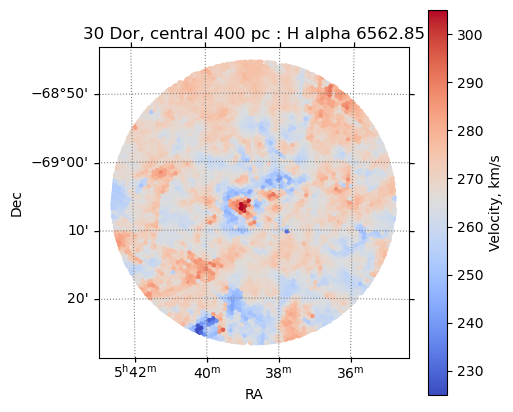

In [13]:
fig, ax = plt.subplots(
    figsize = (5,5),
    subplot_kw=dict(projection=wcs)
)

        
scat = ax.scatter(line_rad.RAdeg, 
           line_rad.DEdeg,
           s= 5,
           c = line_rad.V_mean,
           cmap="coolwarm",
           vmin=225,
           vmax=305,
           transform=ax.get_transform("world")
          )

ax.set_xlabel("RA")
ax.set_ylabel("Dec")
ax.grid(color="gray", ls="dotted")
ax.set_title(f"30 Dor, central 400 pc : H alpha 6562.85")
ax.set_aspect("equal")
fig.colorbar(scat, ax=ax, label="Velocity, km/s")

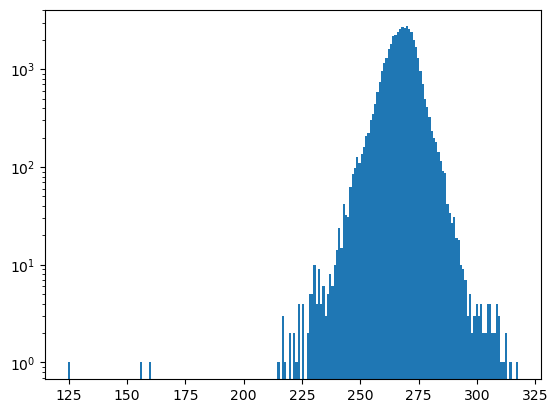

In [14]:
fig, ax = plt.subplots()
plt.hist(line_rad["V_mean"] , bins=200)
ax.set_yscale("log")

In [15]:
mu = line_rad["V_mean"].mean()
sigma = line_rad["V_mean"].std()
n = 3.0

#line_mask = line_rad[np.log10(line_rad["log_F"]) > 0.5]
#line_mask = line_rad[(line_rad["log_F"] > 1000) 
#     & (line_rad["V_mean"] > (mu - n*sigma)) & (line_rad["V_mean"] < (mu + n*sigma))]
mask = (line_rad["V_mean"] > 220) & (line_rad["V_mean"]<330) & (line_rad["log_F"] > 100)  & (line_rad["sigma"] < 1.5) 
#mask = (line_rad["V_mean"] > 240) & (line_rad["V_mean"]<310) & (line_rad["log_F"] > 100) 

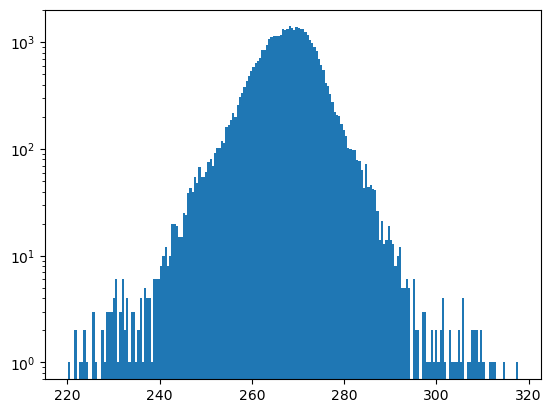

In [16]:
fig, ax = plt.subplots()
plt.hist(line_rad["V_mean"][mask] , bins=200)
ax.set_yscale("log")

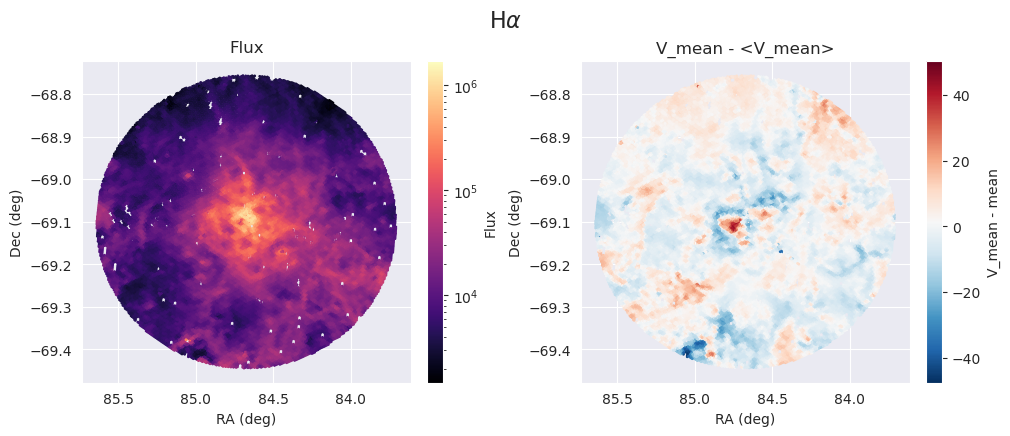

In [17]:
fig, ax = list_maps_plots.plot_panels_log_title(line_rad[mask],
                                                 s=1.0,
                                                figsize=(10, 4.25),
                                                titles=("Flux", "V_mean - <V_mean>"),
                                                figure_title=line)
plt.show()
#plt.savefig('Imgs/' + name_file + '.jpg', bbox_inches='tight')

In [18]:
import lmc_model

In [19]:
df =  line_rad[mask]

In [20]:
c = SkyCoord(ra=df["RAdeg"].to_numpy() * u.deg, dec=df["DEdeg"].to_numpy() * u.deg)
c

<SkyCoord (ICRS): (ra, dec) in deg
    [(84.65      , -69.33053993), (84.67528433, -69.325388  ),
     (84.70055662, -69.32023239), ..., (85.42992956, -69.1498544 ),
     (85.40645637, -69.15584398), (85.38288299, -69.16183337)]>

In [21]:
df.describe()

,RAdeg,DEdeg,V_mean,log_F,sigma
count,42412.000000,42412.000000,42412.000000,4.241200e+04,42412.000000
mean,84.685995,-69.095517,267.552788,3.233409e+04,0.805875
std,0.472181,0.166666,7.071419,7.158410e+04,0.086953
min,83.710625,-69.443836,220.023700,1.469775e+03,0.338400
25%,84.305914,-69.225389,263.629850,6.584452e+03,0.748100
50%,84.696236,-69.096995,267.943300,1.310529e+04,0.788800
75%,85.061549,-68.963314,271.790400,2.915119e+04,0.842000
max,85.638574,-68.756248,317.811500,1.710726e+06,1.499300


In [22]:
vmod = lmc_model.vmodel_lmc(c)
vmod

<Quantity [268.43407919, 268.49018305, 268.54637434, ..., 270.35260472,
           270.28978548, 270.22695919] km / s>

In [23]:
df.insert(
    loc=5,
    column="v_mod",
    value=vmod.value,
)


In [24]:
col = df.pop('V_mean')
df.insert(4, 'v_', col)

In [25]:
df.insert(
    loc=2,
    column="V_mean",
    value= df.v_-df.v_mod,
)

In [26]:
df.describe()

,RAdeg,DEdeg,V_mean,log_F,sigma,v_,v_mod
count,42412.000000,42412.000000,42412.000000,4.241200e+04,42412.000000,42412.000000,42412.000000
mean,84.685995,-69.095517,-2.517466,3.233409e+04,0.805875,267.552788,270.070253
std,0.472181,0.166666,6.920832,7.158410e+04,0.086953,7.071419,1.221113
min,83.710625,-69.443836,-48.218456,1.469775e+03,0.338400,220.023700,267.557538
25%,84.305914,-69.225389,-6.316390,6.584452e+03,0.748100,263.629850,269.084609
50%,84.696236,-69.096995,-2.200581,1.310529e+04,0.788800,267.943300,270.093732
75%,85.061549,-68.963314,1.430164,2.915119e+04,0.842000,271.790400,271.045770
max,85.638574,-68.756248,47.760732,1.710726e+06,1.499300,317.811500,272.539320


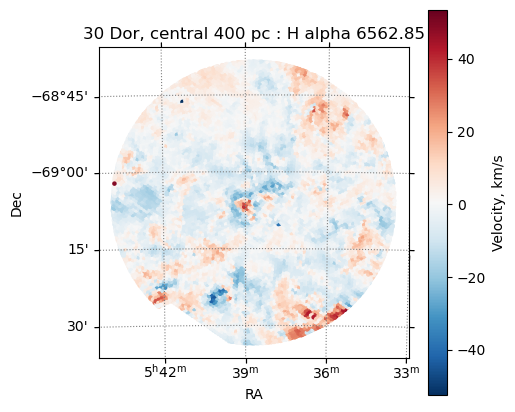

In [27]:
''fig, ax = plt.subplots(
    figsize = (5,5),
    subplot_kw=dict(projection=wcs)
)

        
scat = ax.scatter(df.RAdeg, 
           df.DEdeg,
           s= 5,
           c = df.v_-df.v_mod,
           cmap="RdBu_r",
 #          vmin=225,
 #          vmax=305,
           transform=ax.get_transform("world")
          )

ax.set_xlabel("RA")
ax.set_ylabel("Dec")
ax.grid(color="gray", ls="dotted")
ax.set_title(f"30 Dor, central 400 pc : H alpha 6562.85")
ax.set_aspect("equal")
fig.colorbar(scat, ax=ax, label="Velocity, km/s")

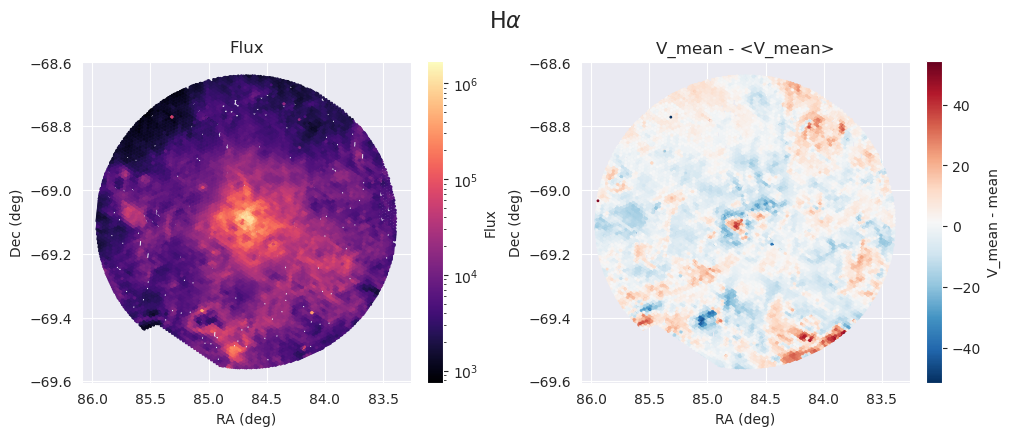

In [28]:
fig, ax = list_maps_plots.plot_panels_log_title(df,
                                                 s=1.0,
                                                figsize=(10, 4.25),
                                                titles=("Flux", "V_mean - <V_mean>"),
                                                figure_title=line)
plt.show()
#plt.savefig('Imgs/' + name_id + '.jpg', bbox_inches='tight')